In [1]:
import os, sys, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
sys.path.append('..')
import power_1loop
from utils_loop import kernel_name_dict

In [4]:
pt = power_1loop.PowerSpectrum1loop()

In [5]:
# Precomputing the PT matrices
# needs to be done once before running MCMCs

names = ['22','13']
names += ['I_d2','I_G2','I_d2_d2','I_G2_G2','I_d2_G2','F_G2']
names += ['I_phi_tilde','I_phi','I_phi_d','I_d2_LPNG','I_G2_LPNG','I_d2_phi-d','I_G2_phi-d','F_G2_LPNG']

pt.set_matrix(names)
pt.compute_matrix(names)

In [6]:
# Running the Boltzamann code (CAMB)
# (the integrations for the IR/UV limit of the power spectrum still raise a precision warning)

cparam = np.array([0.02225,0.1198,0.6844,3.094,0.9645,-1.]) # Planck 2015
pt.set_cosmology(cparam, z=0)

../power_1loop.py:206: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  res = quad(lambda k: self.get_pk_lin(k, khigh=khigh) * k**alpha, kmin, kmax, limit=limit)
../power_1loop.py:206: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  res = quad(lambda k: self.get_pk_lin(k, khigh=khigh) * k**alpha, kmin, kmax, limit=limit)


## Matter power spectrum

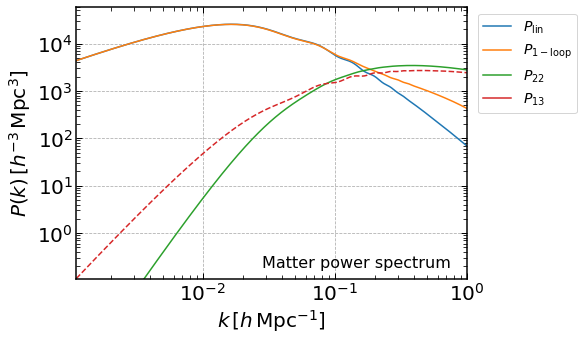

In [7]:
fig = plt.figure(figsize=(7,5))
color = ['gray','royalblue','orangered']
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ls_list = ['-','--','-.']

ax = fig.add_subplot(111)

k = np.logspace(-3,0,1000)
plin = pt.get_pk_lin(k, khigh=40)
p22 = pt.get_pk_1loop(k, name='22')
p13 = pt.get_pk_1loop(k, name='13')

ax.plot(k, plin, ls='-', c=color[0], label=r'$P_\mathrm{lin}$')
ax.plot(k, plin+p22+p13, ls='-', c=color[1], label=r'$P_{1-\mathrm{loop}}$')

ax.plot(k, p22, ls='-', c=color[2], label=r'$P_{22}$')
ax.plot(k, -p22, ls='--', c=color[2])
ax.plot(k, p13, ls='-', c=color[3], label=r'$P_{13}$')
ax.plot(k, -p13, ls='--', c=color[3])
ax.text(0.96, 0.04, 'Matter power spectrum', fontsize=16, transform=ax.transAxes, ha='right')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$P(k)\,[h^{-3}\,\mathrm{Mpc}^3]$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(0.0011,1)
    plt.ylim(0.11,6e+4)
    plt.legend(fontsize=14, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

## Galaxy bias terms (Gaussian initial conditions)

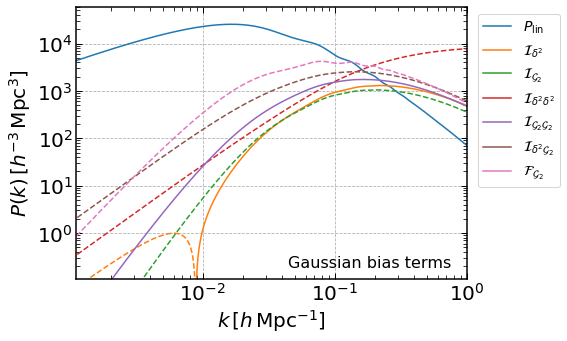

In [8]:
fig = plt.figure(figsize=(7,5))
color = ['gray','royalblue','orangered']
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ls_list = ['-','--','-.']

ax = fig.add_subplot(111)

k = np.logspace(-3,0,1000)
plin = pt.get_pk_lin(k)
ax.plot(k, plin, ls='-', c=color[0], label=r'$P_\mathrm{lin}$')

name_list = ['I_d2','I_G2','I_d2_d2','I_G2_G2','I_d2_G2','F_G2']
for i, name in enumerate(name_list):
    sub_k0 = True if name == 'I_d2_d2' else False
    pk = pt.get_pk_1loop(k, name=name, sub_k0=sub_k0)
    ax.plot(k, pk, ls='-', c=color[i+1], label=r'$%s$' % (kernel_name_dict[name]))
    ax.plot(k, -pk, ls='--', c=color[i+1])
ax.text(0.96, 0.04, 'Gaussian bias terms', fontsize=16, transform=ax.transAxes, ha='right')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$P(k)\,[h^{-3}\,\mathrm{Mpc}^3]$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(0.0011,1)
    plt.ylim(0.11,6e+4)
    plt.legend(fontsize=14, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

## Galaxy bias terms coming from local PNG

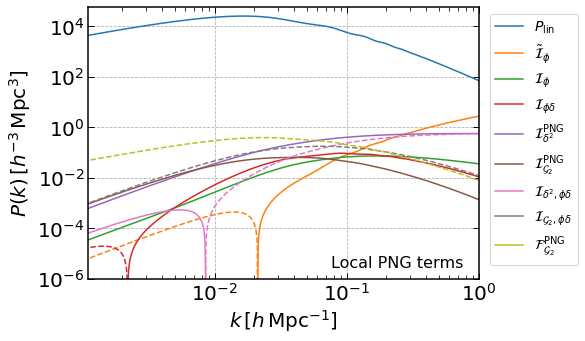

In [9]:
fig = plt.figure(figsize=(7,5))
color = ['gray','royalblue','orangered']
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ls_list = ['-','--','-.']

ax = fig.add_subplot(111)

k = np.logspace(-3,0,1000)
plin = pt.get_pk_lin(k)
ax.plot(k, plin, ls='-', label=r'$P_\mathrm{lin}$')

name_list = ['I_phi_tilde','I_phi','I_phi_d','I_d2_LPNG','I_G2_LPNG','I_d2_phi-d','I_G2_phi-d','F_G2_LPNG']
for i, name in enumerate(name_list):
    sub_k0 = True if name == 'I_d2_phi-d' or 'I_d2_LPNG' else False
    pk = pt.get_pk_1loop(k, name=name, sub_k0=sub_k0)
    ax.plot(k, pk, ls='-', c=color[i+1], label=r'$%s$' % (kernel_name_dict[name]))
    ax.plot(k, -pk, ls='--', c=color[i+1])
ax.text(0.96, 0.04, 'Local PNG terms', fontsize=16, transform=ax.transAxes, ha='right')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$P(k)\,[h^{-3}\,\mathrm{Mpc}^3]$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(0.0011,1)
    plt.ylim(1e-6,6e+4)
    plt.legend(fontsize=14, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')